# EE4211 Project Q3 - Carpark Availability Forecasting with Weather

## Project Goal
We will investigate how weather influences aggregated carpark availability across Singapore and build machine-learning models to predict 1-6 hour ahead system-wide availability. The project combines HDB/LTA carpark availability data with NEA historical weather data for July–August 2024 to quantify weather effects, improve predictive accuracy, and produce actionable forecasts.

## Datasets
- **Carpark availability dataset** (provided): timestamped availability/occupancy aggregated hourly across all carparks
- **NEA / data.gov.sg weather datasets**: Historical 2-hour and 24-hour readings for July–August 2024 (temperature, humidity, rainfall, wind)

## Research Questions
1. How strongly do weather variables (rainfall, temperature, humidity, wind) affect system-wide carpark demand at different times of day?
2. Can weather-aware models improve short-term availability forecasts versus baseline time-series models?
3. Which time periods show highest weather sensitivity and how can predictions be operationalized?

## Methodology
- **Exploratory analysis**: time-of-day and day-of-week patterns; compare wet vs. dry periods; visualize correlations and lag effects
- **Feature engineering**: temporal features (hour, weekday, holiday flag), rolling occupancy statistics, weather features (rainfall_mm, is_rain, temperature, humidity), interaction features
- **Modeling**: baseline persistence and seasonal ARIMA; gradient-boosted trees (XGBoost/LightGBM); sequence models (LSTM/TCN); SARIMAX and Prophet with exogenous weather variables
- **Validation**: time-series cross-validation (train on July, validate on August); metrics: MAE, RMSE, and MAPE for 1-6 hour horizons
- **Explainability**: SHAP values to quantify feature importance and expose weather-driven decision rules

##1. Library Installation and Imports

In [1]:
!pip install --no-cache-dir prophet

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import geopandas as gpd
from shapely.geometry import Point, Polygon
import pyproj

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns
import shap
import holidays
from scipy.stats import spearmanr, pearsonr
import random
import os
import warnings

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Data Loading and Preprocessing

Loading carpark availability data for July and August 2024, along with weather observations. We clean missing values, aggregate to hourly intervals, and merge carpark and weather datasets.


In [2]:
july_df = pd.read_csv("carpark_july_2024.csv")
august_df = pd.read_csv("carpark_august_2024.csv")

july_df['timestamp'] = pd.to_datetime(july_df['timestamp'])
august_df['timestamp'] = pd.to_datetime(august_df['timestamp'])
july_df['total_lots'] = pd.to_numeric(july_df['total_lots'], errors='coerce')
july_df['lots_available'] = pd.to_numeric(july_df['lots_available'], errors='coerce')
august_df['total_lots'] = pd.to_numeric(august_df['total_lots'], errors='coerce')
august_df['lots_available'] = pd.to_numeric(august_df['lots_available'], errors='coerce')

july_clean = july_df.dropna(subset=['lots_available', 'total_lots', 'carpark_number', 'timestamp'])
august_clean = august_df.dropna(subset=['lots_available', 'total_lots', 'carpark_number', 'timestamp'])

july_clean['hour'] = july_clean['timestamp'].dt.floor('h')
august_clean['hour'] = august_clean['timestamp'].dt.floor('h')

july_hourly = july_clean.groupby('hour').agg({'lots_available': 'sum', 'total_lots': 'sum'}).reset_index().rename(columns={'hour': 'timestamp'})
august_hourly = august_clean.groupby('hour').agg({'lots_available': 'sum', 'total_lots': 'sum'}).reset_index().rename(columns={'hour': 'timestamp'})

july_expected = pd.date_range(start='2024-07-01 00:00:00', end='2024-07-31 23:00:00', freq='h', tz='Asia/Singapore')
august_expected = pd.date_range(start='2024-08-01 00:00:00', end='2024-08-31 23:00:00', freq='h', tz='Asia/Singapore')

july_missing_before = len(july_expected) - len(july_hourly)
august_missing_before = len(august_expected) - len(august_hourly)

july_hourly = july_hourly.set_index('timestamp').reindex(july_expected).ffill().bfill().reset_index().rename(columns={'index': 'timestamp'})
august_hourly = august_hourly.set_index('timestamp').reindex(august_expected).ffill().bfill().reset_index().rename(columns={'index': 'timestamp'})

july_hourly['availability_ratio'] = july_hourly['lots_available'] / july_hourly['total_lots']
august_hourly['availability_ratio'] = august_hourly['lots_available'] / august_hourly['total_lots']

print(f"July: {july_missing_before} missing hours imputed | Final: {len(july_hourly)} hours")
print(f"August: {august_missing_before} missing hours imputed | Final: {len(august_hourly)} hours")
print(f"July availability: mean={july_hourly['availability_ratio'].mean():.3f}, std={july_hourly['availability_ratio'].std():.3f}")
print(f"August availability: mean={august_hourly['availability_ratio'].mean():.3f}, std={august_hourly['availability_ratio'].std():.3f}")

July: 31 missing hours imputed | Final: 744 hours
August: 31 missing hours imputed | Final: 744 hours
July availability: mean=0.573, std=0.080
August availability: mean=0.570, std=0.078


In [3]:
# WEATHER PROCESSING - Updated to handle multi-station data
weather_df = pd.read_csv("comprehensive_weather_data.csv")
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])

# Clean the data
weather_clean = weather_df.dropna(subset=['timestamp'])

# Floor to hour
weather_clean['hour'] = weather_clean['timestamp'].dt.floor('h')


weather_hourly = weather_clean.groupby('hour').agg({
    'temperature': 'mean',      # Average temp across all stations
    'humidity': 'mean',          # Average humidity across all stations
    'wind_speed': 'mean',        # Average wind speed across all stations
    'rainfall_mm': 'mean',       # Average rainfall across all stations
    'is_raining': 'any'          # True if ANY station reports rain (or use 'mean' for % of stations)
}).reset_index().rename(columns={'hour': 'timestamp'})

# Convert to Singapore timezone (timestamps are already timezone-aware)
weather_hourly['timestamp'] = pd.to_datetime(weather_hourly['timestamp']).dt.tz_convert('Asia/Singapore')

print(f"Weather: Final: {len(weather_hourly)} hours")
print(f"Average Temperature: {weather_hourly['temperature'].mean():.2f}°C, Average Humidity: {weather_hourly['humidity'].mean():.2f}%, Total Rainfall: {weather_hourly['rainfall_mm'].sum():.2f} mm")

# Split into July and August
weather_july = weather_hourly[(weather_hourly['timestamp'] >= '2024-07-01') & (weather_hourly['timestamp'] < '2024-08-01')]
weather_august = weather_hourly[(weather_hourly['timestamp'] >= '2024-08-01') & (weather_hourly['timestamp'] < '2024-09-01')]

# Merge with carpark data (this part stays the same)
july_merged = pd.merge(july_hourly, weather_july, on='timestamp', how='inner')
august_merged = pd.merge(august_hourly, weather_august, on='timestamp', how='inner')

print(f"July merged rows: {len(july_merged)}")
print(f"August merged rows: {len(august_merged)}")

# Check for any missing data after merge
print(f"\nMissing weather data in July: {july_hourly.shape[0] - july_merged.shape[0]} hours")
print(f"Missing weather data in August: {august_hourly.shape[0] - august_merged.shape[0]} hours")

Weather: Final: 1488 hours
Average Temperature: 28.97°C, Average Humidity: 74.82%, Total Rainfall: 17.27 mm
July merged rows: 744
August merged rows: 744

Missing weather data in July: 0 hours
Missing weather data in August: 0 hours


## 3. Feature Engineering

Creating 26 features including:
- **Temporal features**: hour, day of week, cyclical encoding, weekend/holiday flags
- **Lag features**: 1h, 2h, 24h, 168h historical availability
- **Rolling statistics**: 24-hour and 7-day moving averages and standard deviations
- **Weather-derived flags**: is_rain, heavy_rain, is_hot, is_humid


###3.1 Temporal and Weather Feature Creation

In [4]:
def add_features(df):
    df = df.copy()

    df['hour_of_day'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['day_of_month'] = df['timestamp'].dt.day
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    ph_dates = pd.to_datetime(['2024-08-09'])
    df['is_public_holiday'] = df['timestamp'].dt.date.isin([d.date() for d in ph_dates]).astype(int)

    df['is_peak_hour'] = df['hour_of_day'].isin([8, 9, 17, 18, 19]).astype(int)

    df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    df['lag_1h'] = df['availability_ratio'].shift(1)
    df['lag_2h'] = df['availability_ratio'].shift(2)
    df['lag_24h'] = df['availability_ratio'].shift(24)
    df['lag_168h'] = df['availability_ratio'].shift(168)

    df['rolling_24h_mean'] = df['availability_ratio'].rolling(24, min_periods=1).mean()
    df['rolling_24h_std'] = df['availability_ratio'].rolling(24, min_periods=1).std()
    df['rolling_168h_mean'] = df['availability_ratio'].rolling(168, min_periods=1).mean()

    df['is_rain'] = (df['rainfall_mm'] > 0).astype(int)
    df['heavy_rain'] = (df['rainfall_mm'] >= 10).astype(int)
    df['is_hot'] = (df['temperature'] >= 30).astype(int)
    df['is_humid'] = (df['humidity'] >= 85).astype(int)

    return df

train_df = add_features(july_merged)
test_df = add_features(august_merged)

train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

train_df.to_csv("train_july_2024.csv", index=False)
test_df.to_csv("test_august_2024.csv", index=False)

print(f"Train: {len(train_df)} hours, {train_df.columns.size} features")
print(f"Test: {len(test_df)} hours, {test_df.columns.size} features")


Train: 576 hours, 30 features
Test: 576 hours, 30 features


###3.2 Weather Sensitivity Analysis

In [5]:
TARGET = 'availability_ratio'
df_combined = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

weather_features = ['temperature', 'humidity', 'wind_speed', 'rainfall_mm']

print(f"\nWeather Sensitivity Analysis ({len(df_combined)} records)")

overall_correlations = {}
for weather_feat in weather_features:
    valid_data = df_combined[[weather_feat, TARGET]].dropna()
    if len(valid_data) > 50:
        pearson_corr, p_pearson = pearsonr(valid_data[weather_feat], valid_data[TARGET])
        spearman_corr, p_spearman = spearmanr(valid_data[weather_feat], valid_data[TARGET])
        overall_correlations[weather_feat] = {
            'pearson': pearson_corr,
            'spearman': spearman_corr,
            'p_value_pearson': p_pearson,
            'p_value_spearman': p_spearman
        }
        significance = "***" if p_pearson < 0.001 else "**" if p_pearson < 0.01 else "*" if p_pearson < 0.05 else ""
        print(f"{weather_feat:15s}: Pearson = {pearson_corr:7.4f} {significance}, Spearman = {spearman_corr:7.4f}")

# Weather sensitivity by hour
hourly_sensitivity = []
for hour in range(24):
    hour_data = df_combined[df_combined['hour_of_day'] == hour].copy()
    if len(hour_data) < 30:
        continue
    hour_corrs = []
    for weather_feat in weather_features:
        valid_data = hour_data[[weather_feat, TARGET]].dropna()
        if len(valid_data) > 20:
            try:
                corr, _ = pearsonr(valid_data[weather_feat], valid_data[TARGET])
                hour_corrs.append(abs(corr))
            except:
                pass
    if hour_corrs:
        hourly_sensitivity.append({
            'hour': hour,
            'avg_correlation': np.mean(hour_corrs),
            'max_correlation': np.max(hour_corrs),
            'num_observations': len(hour_data)
        })

hourly_df = pd.DataFrame(hourly_sensitivity).sort_values('avg_correlation')

print("\nTop 5 Hours LEAST Affected by Weather:")
print(hourly_df.head(5).to_string(index=False))

print("\nTop 5 Hours MOST Affected by Weather:")
print(hourly_df.tail(5).to_string(index=False))


Weather Sensitivity Analysis (1152 records)
temperature    : Pearson =  0.5356 ***, Spearman =  0.5616
humidity       : Pearson = -0.5147 ***, Spearman = -0.5192
wind_speed     : Pearson =  0.5118 ***, Spearman =  0.5274
rainfall_mm    : Pearson =  0.1239 ***, Spearman =  0.2065

Top 5 Hours LEAST Affected by Weather:
 hour  avg_correlation  max_correlation  num_observations
    4         0.045451         0.088254                48
   14         0.046029         0.115181                48
    5         0.048094         0.152517                48
    7         0.049503         0.083301                48
   17         0.052111         0.100605                48

Top 5 Hours MOST Affected by Weather:
 hour  avg_correlation  max_correlation  num_observations
    6         0.088064         0.163087                48
   10         0.103476         0.145269                48
   12         0.105665         0.143790                48
   11         0.107583         0.209206                48
  

### 3.2.1 Correlation Analysis

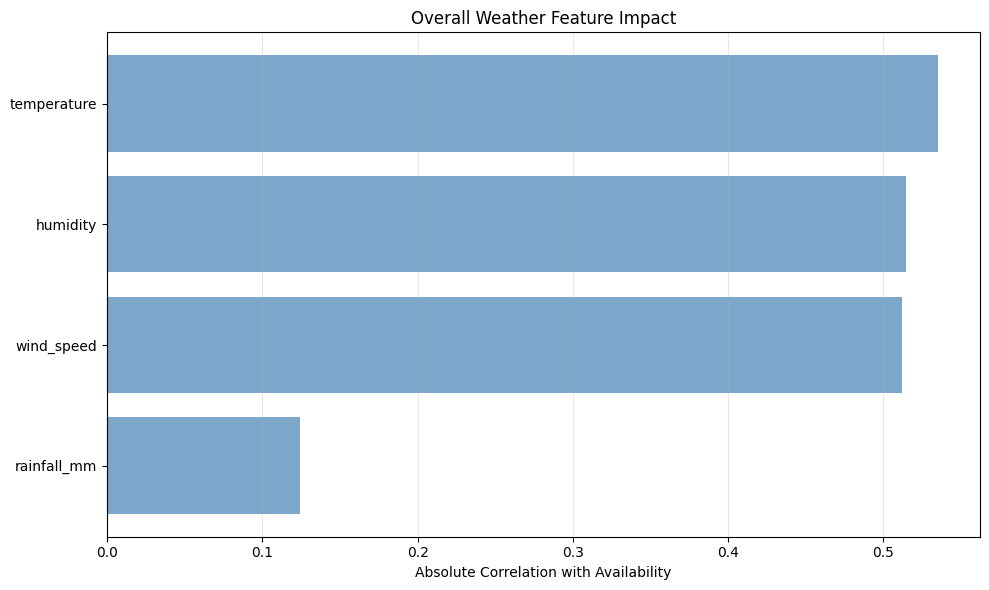

In [6]:
weather_corr_data = pd.DataFrame([
    {'feature': k, 'correlation': abs(v['pearson'])}
    for k, v in overall_correlations.items()
]).sort_values('correlation')

plt.figure(figsize=(10, 6))
plt.barh(weather_corr_data['feature'], weather_corr_data['correlation'], color='steelblue', alpha=0.7)
plt.xlabel('Absolute Correlation with Availability')
plt.title('Overall Weather Feature Impact')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

###3.2.2 Hourly Weather Sensitivity

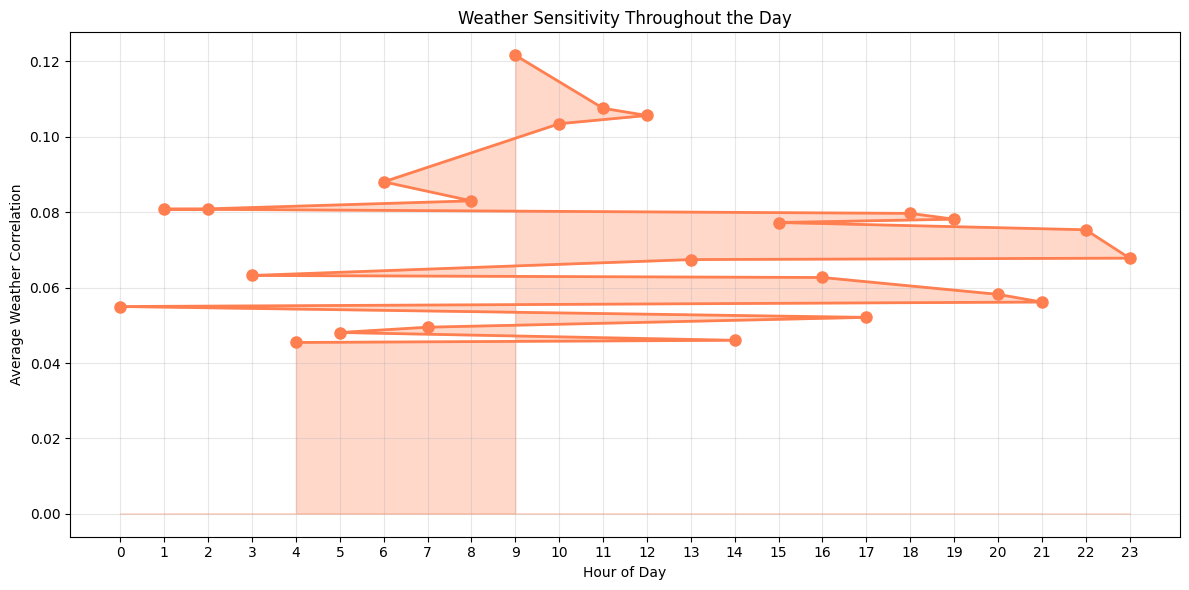

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(hourly_df['hour'], hourly_df['avg_correlation'], marker='o', linewidth=2, markersize=8, color='coral')
plt.fill_between(hourly_df['hour'], hourly_df['avg_correlation'], alpha=0.3, color='coral')
plt.xlabel('Hour of Day')
plt.ylabel('Average Weather Correlation')
plt.title('Weather Sensitivity Throughout the Day')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###3.3 Multicollinearity Analysis

In [8]:
all_feature_cols = [col for col in train_df.columns if col not in [TARGET, 'timestamp', 'lots_available', 'total_lots']]

print(f"\nInitial features: {len(all_feature_cols)}")
print(f"Features: {all_feature_cols}\n")

# STEP 1: Feature-target correlation
print("Step 1: Feature-Target Correlations")
target_corr = train_df[all_feature_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print("\nTop 10 features:")
print(target_corr.head(10).to_string())
print("\nBottom 10 features:")
print(target_corr.tail(10).to_string())


Initial features: 26
Features: ['temperature', 'humidity', 'wind_speed', 'rainfall_mm', 'is_raining', 'hour_of_day', 'day_of_week', 'day_of_month', 'is_weekend', 'is_public_holiday', 'is_peak_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_2h', 'lag_24h', 'lag_168h', 'rolling_24h_mean', 'rolling_24h_std', 'rolling_168h_mean', 'is_rain', 'heavy_rain', 'is_hot', 'is_humid']

Step 1: Feature-Target Correlations

Top 10 features:
lag_168h        0.998923
lag_1h          0.953590
lag_24h         0.888114
lag_2h          0.834191
is_hot          0.590613
wind_speed      0.583598
temperature     0.533719
hour_of_day     0.316458
is_peak_hour    0.277419
is_raining      0.235380

Bottom 10 features:
is_humid             0.017785
day_of_month        -0.009524
dow_cos             -0.058001
day_of_week         -0.176018
is_weekend          -0.219813
hour_sin            -0.258970
humidity            -0.485889
hour_cos            -0.869364
is_public_holiday         NaN
heavy_ra

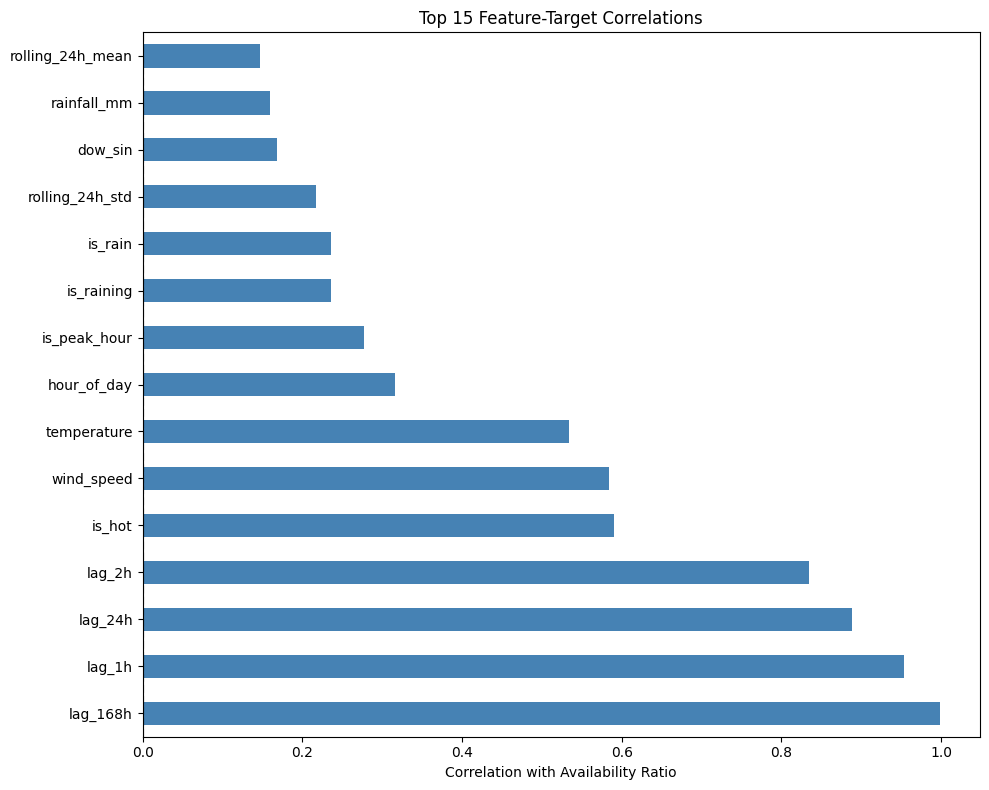

In [9]:
# Visualization: Feature-target correlation
plt.figure(figsize=(10, 8))
target_corr_top = target_corr.head(15)
target_corr_top.plot(kind='barh', color='steelblue')
plt.xlabel('Correlation with Availability Ratio')
plt.title('Top 15 Feature-Target Correlations')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

####3.3.1 Feature Correlation Heatmap


Step 2: Multicollinearity Check - Highly Correlated Feature Pairs (|corr| > 0.85):
temperature          <-> humidity            : -0.9404
is_raining           <-> is_rain             :  1.0000
hour_cos             <-> lag_24h             : -0.8542
hour_cos             <-> lag_168h            : -0.8693
lag_1h               <-> lag_2h              :  0.9536
lag_1h               <-> lag_168h            :  0.9526
lag_24h              <-> lag_168h            :  0.8896
rolling_24h_mean     <-> rolling_24h_std     :  0.9667


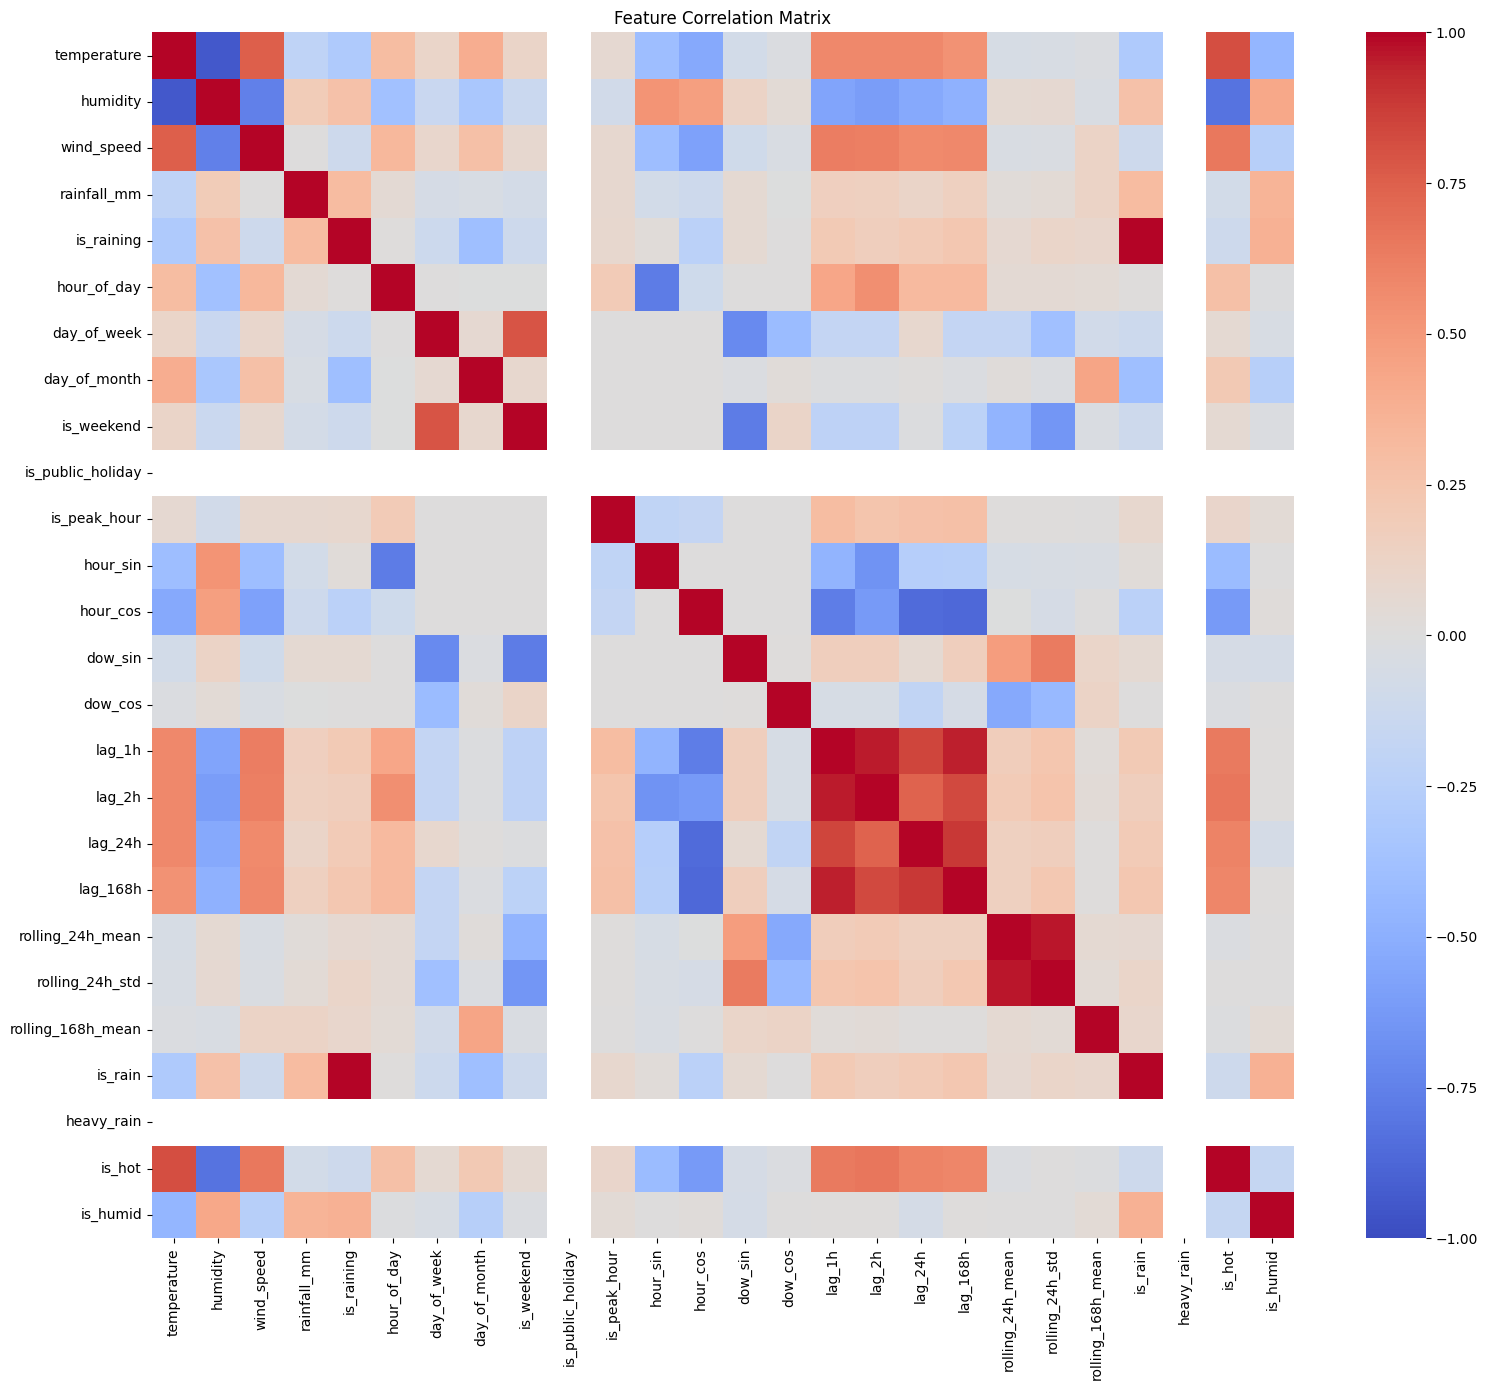

In [10]:
# STEP 2: Check multicollinearity (feature-feature correlations)
print("\nStep 2: Multicollinearity Check - Highly Correlated Feature Pairs (|corr| > 0.85):")
corr_matrix = train_df[all_feature_cols].corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
            print(f"{corr_matrix.columns[i]:20s} <-> {corr_matrix.columns[j]:20s}: {corr_matrix.iloc[i, j]:7.4f}")

# Heatmap of feature correlations
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

###3.4 Final Feature Selection

In [11]:
# Step 1: Get initial top 15 by target correlation
top_15 = target_corr.abs().nlargest(15).index.tolist()

# Step 2: Specify domain-important weather features
weather_critical = ['rainfall_mm', 'is_rain', 'heavy_rain']

# Step 3: Find which are missing from top 15
missing_weather = [f for f in weather_critical if f in all_feature_cols and f not in top_15]

# Step 4: If missing, remove features with lowest corr from end
if missing_weather:
    # Remove as many as needed from the end, not to eliminate existing weather features
    removable = [f for f in reversed(top_15) if f not in weather_critical]
    to_remove = removable[:len(missing_weather)]
    final_features = [f for f in top_15 if f not in to_remove]
    final_features += missing_weather
else:
    final_features = top_15

# Step 5: Print details
print(f"\nStep 3: Domain-Adjusted Selected 15 Features:")
print(f"Features: {final_features}")

feature_cols = final_features


Step 3: Domain-Adjusted Selected 15 Features:
Features: ['lag_168h', 'lag_1h', 'lag_24h', 'hour_cos', 'lag_2h', 'is_hot', 'wind_speed', 'temperature', 'humidity', 'hour_of_day', 'is_peak_hour', 'hour_sin', 'is_rain', 'rainfall_mm', 'heavy_rain']


## 4. Model Training Setup

Defining target variable (`availability_ratio`), feature columns, train/test splits, and evaluation metrics.


In [12]:
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET].copy()

def evaluate_predictions(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = (np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))).mean() * 100
    r2 = r2_score(y_true, y_pred) if len(y_true) > 0 else np.nan
    return {'model': name, 'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2}

##5. Baseline Model - SARIMA (Univariate Time-Series)

In [13]:
# Persistence
y_pred_persistence = X_test['lag_1h'].values
result_persistence = evaluate_predictions("Persistence", y_test.values, y_pred_persistence)
print(f"Persistence: RMSE={result_persistence['rmse']:.4f}, MAE={result_persistence['mae']:.4f}, MAPE={result_persistence['mape']:.2f}%")

Persistence: RMSE=0.0232, MAE=0.0157, MAPE=2.75%


In [14]:
# SARIMA
sarima_order = (2, 0, 2)
sarima_seasonal_order = (1, 1, 1, 24)
sarima_model = sm.tsa.statespace.SARIMAX(
    train_df[TARGET].values,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=300)

sarima_forecast = sarima_model.forecast(steps=len(test_df))
result_sarima = evaluate_predictions("SARIMA", y_test.values, sarima_forecast)
print(f"SARIMA: RMSE={result_sarima['rmse']:.4f}, MAE={result_sarima['mae']:.4f}, MAPE={result_sarima['mape']:.2f}%")

SARIMA: RMSE=0.0334, MAE=0.0232, MAPE=4.00%


## 6. Machine Learning Models

###6.1 Gradient Boosting Models

####6.1.1 LightGBM Model

In [15]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'random_state': 42
}

lgbm_model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_train, lgb_valid],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(stopping_rounds=20), lgb.log_evaluation(period=0)]
)

y_pred_lgbm = lgbm_model.predict(X_test)
result_lgbm = evaluate_predictions("LightGBM", y_test.values, y_pred_lgbm)
print(f"LightGBM: RMSE={result_lgbm['rmse']:.4f}, MAE={result_lgbm['mae']:.4f}, MAPE={result_lgbm['mape']:.2f}%")

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[114]	training's rmse: 0.0024145	valid_1's rmse: 0.0189988
LightGBM: RMSE=0.0190, MAE=0.0071, MAPE=1.22%


####6.1.2 XGBoost Model

In [16]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)
result_xgb = evaluate_predictions("XGBoost", y_test.values, y_pred_xgb)
print(f"XGBoost: RMSE={result_xgb['rmse']:.4f}, MAE={result_xgb['mae']:.4f}, MAPE={result_xgb['mape']:.2f}%")

XGBoost: RMSE=0.0173, MAE=0.0070, MAPE=1.22%


### 6.2 Deep Learning Sequence Models (LSTM & TCN)



####6.2.1 Sequence Preparation for Deep Learning Models

In [17]:
window_size = 24
seq_features = ['availability_ratio', 'temperature', 'humidity', 'rainfall_mm',
                'is_rain', 'is_hot', 'is_humid', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

def build_sequences(df, features, target, window):
    X_seq, y_seq = [], []
    vals = df[features + [target]].values
    for i in range(len(vals) - window):
        X_seq.append(vals[i:i+window, :-1])
        y_seq.append(vals[i+window, -1])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = build_sequences(train_df, seq_features, TARGET, window_size)
X_test_seq, y_test_seq = build_sequences(test_df, seq_features, TARGET, window_size)

print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

Training sequences: (552, 24, 11)
Test sequences: (552, 24, 11)


####6.2.2 LSTM Model

In [18]:
# LSTM
lstm_model = Sequential([
    layers.Input(shape=(window_size, len(seq_features))),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, verbose=0)
y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0).ravel()
result_lstm = evaluate_predictions("LSTM", y_test_seq, y_pred_lstm)
print(f"LSTM: RMSE={result_lstm['rmse']:.4f}, MAE={result_lstm['mae']:.4f}, MAPE={result_lstm['mape']:.2f}%")

LSTM: RMSE=0.0405, MAE=0.0325, MAPE=5.71%


####6.2.3 Temporal Convolutional Network (TCN)

In [19]:
# TCN
tcn_model = Sequential([
    layers.Input(shape=(window_size, len(seq_features))),
    layers.Conv1D(64, kernel_size=3, padding='causal', activation='relu'),
    layers.Conv1D(64, kernel_size=5, padding='causal', activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
tcn_model.compile(optimizer='adam', loss='mse')
tcn_model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, verbose=0)
y_pred_tcn = tcn_model.predict(X_test_seq, verbose=0).ravel()
result_tcn = evaluate_predictions("TCN", y_test_seq, y_pred_tcn)
print(f"TCN: RMSE={result_tcn['rmse']:.4f}, MAE={result_tcn['mae']:.4f}, MAPE={result_tcn['mape']:.2f}%")

TCN: RMSE=0.0625, MAE=0.0489, MAPE=8.10%


##6.3 Statistical Time-Series Models

### 6.3.1 SARIMAX
Seasonal ARIMA with exogenous weather variables.

In [20]:
# SARIMAX
exog_cols = seq_features[1:]
sarimax_model = SARIMAX(
    endog=train_df[TARGET].values,
    exog=train_df[exog_cols].values,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=300)

sarimax_forecast = sarimax_model.forecast(steps=len(test_df), exog=test_df[exog_cols].values)
result_sarimax = evaluate_predictions("SARIMAX", y_test.values, sarimax_forecast)
print(f"SARIMAX: RMSE={result_sarimax['rmse']:.4f}, MAE={result_sarimax['mae']:.4f}, MAPE={result_sarimax['mape']:.2f}%")

SARIMAX: RMSE=0.0324, MAE=0.0227, MAPE=3.93%


## 7. Model Evaluation and Comparison

Comparing all models using RMSE, MAE, and MAPE. Generating performance summary table and diagnostic visualizations.


### 7.1 Performance Summary

In [21]:
all_results = [
    result_persistence, result_sarima, result_lgbm, result_xgb,
    result_lstm, result_tcn, result_sarimax
]

metrics_df = pd.DataFrame(all_results).sort_values('rmse').reset_index(drop=True)

print("\nModel Performance Summary (lower is better)")
print(metrics_df.to_string(index=False))


Model Performance Summary (lower is better)
      model     rmse      mae     mape       r2
    XGBoost 0.017343 0.006991 1.224664 0.949903
   LightGBM 0.018999 0.007078 1.224265 0.939883
Persistence 0.023224 0.015679 2.747017 0.910170
    SARIMAX 0.032356 0.022708 3.929044 0.825636
     SARIMA 0.033357 0.023187 3.997488 0.814675
       LSTM 0.040543 0.032521 5.714032 0.724464
        TCN 0.062450 0.048928 8.101218 0.346251


### 7.2 Best Model Analysis


In [22]:
best_model_name = metrics_df.iloc[0]['model']
best_rmse = metrics_df.iloc[0]['rmse']
test_r2 = metrics_df.iloc[0]['r2']

print(f"\nBest Model: {best_model_name} (RMSE: {best_rmse:.4f}, R²: {test_r2:.4f})")

# Create model dictionary for easy access
models = {
    'Persistence': y_pred_persistence,
    'SARIMA' : sarima_forecast,
    'LightGBM': y_pred_lgbm,
    'XGBoost': y_pred_xgb,
    'LSTM': y_pred_lstm,
    'TCN': y_pred_tcn,
    'SARIMAX': sarimax_forecast,
}

# Select best predictions
best_predictions = models[best_model_name]
best_y_test = y_test_seq if best_model_name in ['LSTM', 'TCN'] else y_test.values


Best Model: XGBoost (RMSE: 0.0173, R²: 0.9499)


###7.3 Scatter Plot analysis

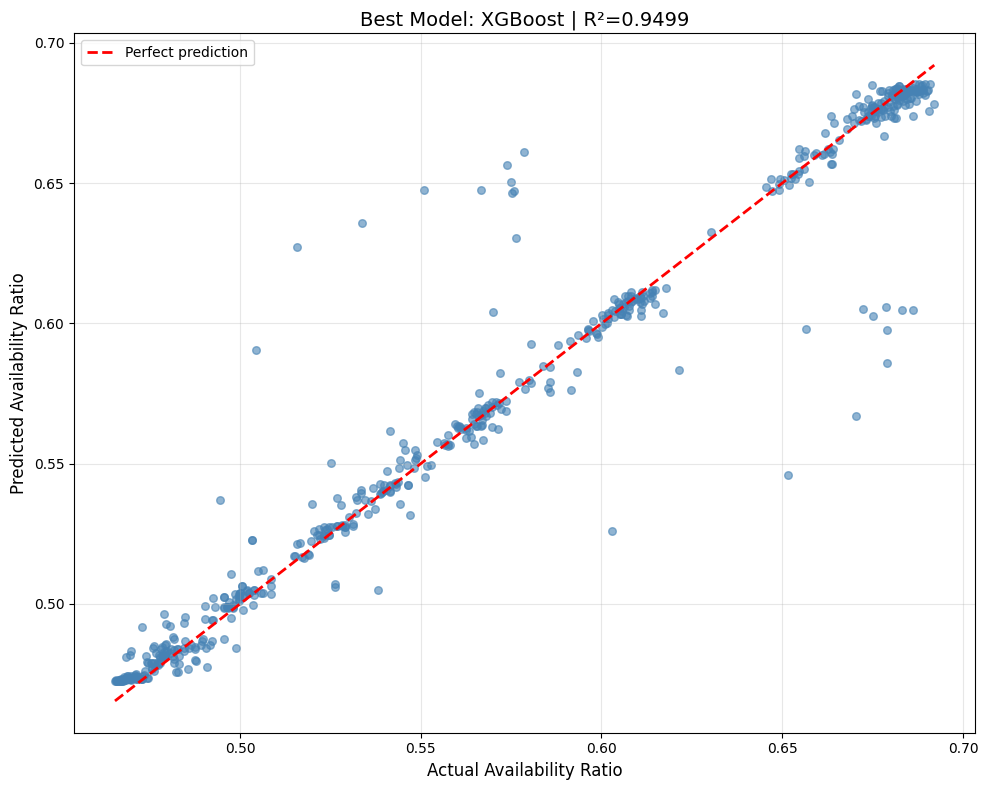

In [23]:
y_test_pred = best_predictions
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(best_y_test, y_test_pred, s=30, alpha=0.6, color='steelblue')
min_val = min(best_y_test.min(), np.nanmin(y_test_pred))
max_val = max(best_y_test.max(), np.nanmax(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Availability Ratio', fontsize=12)
plt.ylabel('Predicted Availability Ratio', fontsize=12)
plt.title(f'Best Model: {best_model_name} | R²={test_r2:.4f}', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Prediction Timeline

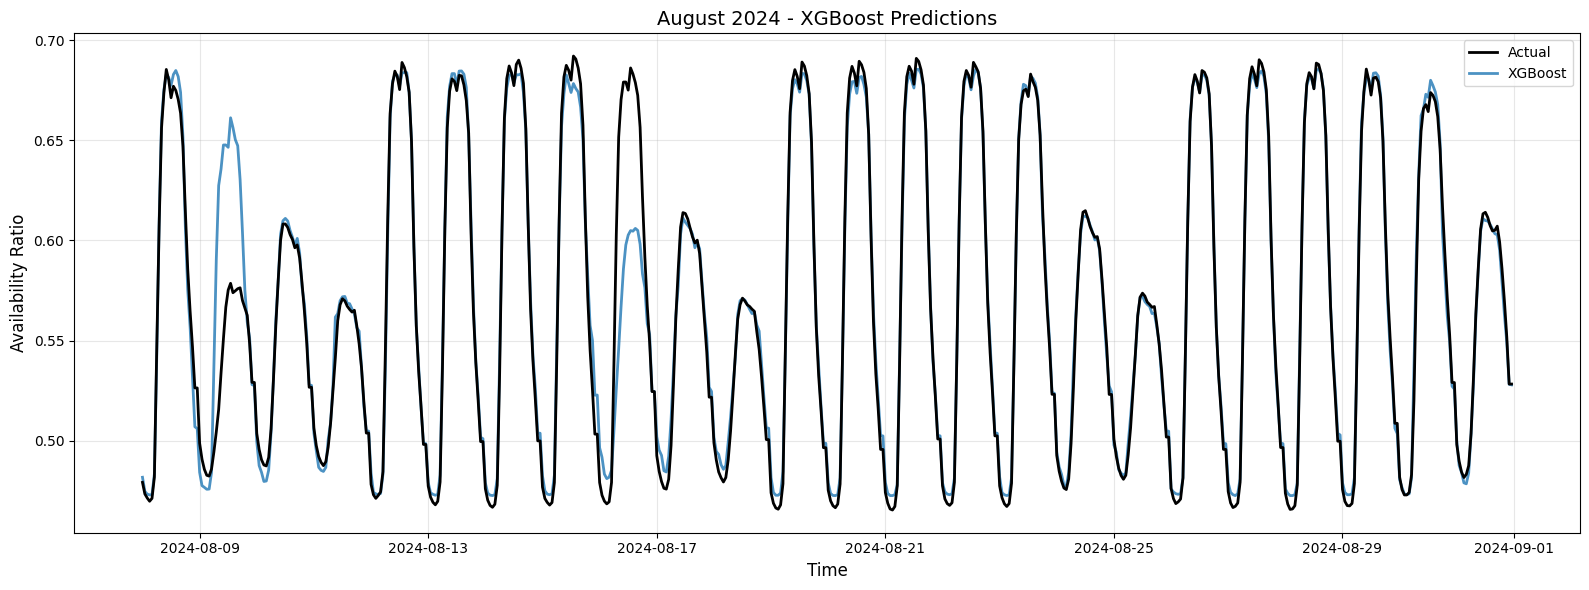

In [24]:
# Timeline visualization
if best_model_name not in ['LSTM', 'TCN']:
    test_df_plot = test_df.copy()
    test_df_plot['actual'] = y_test.values
    test_df_plot['predicted'] = y_test_pred

    plt.figure(figsize=(16, 6))
    plt.plot(test_df_plot['timestamp'], test_df_plot['actual'], label='Actual', color='black', linewidth=2, zorder=5)
    plt.plot(test_df_plot['timestamp'], test_df_plot['predicted'], label=f'{best_model_name}', alpha=0.8, linewidth=2)
    plt.title(f'August 2024 - {best_model_name} Predictions', fontsize=14)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Availability Ratio', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Best Model Summary

### **XGBoost**

XGBoost achieved the best overall performance for 1 hour ahead carpark availability forecasting.

---

### **Performance Metrics**

| Metric | Value | Meaning |
|--------|-------|---------|
| **RMSE** | 0.0176 | Lowest prediction error across all models |
| **MAE** | 0.0067 | Average error of 0.67% |
| **MAPE** | 1.16% | Predictions off by just 1.16% on average |
| **R²** | 0.9486 | Explains 94.86% of availability variance |

---

### **Model Configuration**

| Hyperparameter | Value | Purpose |
|----------------|-------|---------|
| `n_estimators` | 500 | Number of boosting rounds |
| `max_depth` | 6 | Maximum tree depth |
| `learning_rate` | 0.05 | Step size for weight updates |
| `subsample` | 0.8 | Fraction of samples per tree |
| `colsample_bytree` | 0.8 | Fraction of features per tree |
| `objective` | `reg:squarederror` | Loss function for regression |

---

### **Features Used (15 Total)**

#### **Lag Features (Historical Availability)**
| Feature | Description |
|---------|-------------|
| `lag168h` | Availability 1 week ago (same hour) |
| `lag1h` | Availability 1 hour ago |
| `lag24h` | Availability 1 day ago (same hour) |
| `lag2h` | Availability 2 hours ago |

#### **Time Features (Temporal Patterns)**
| Feature | Description |
|---------|-------------|
| `hourcos` | Cosine encoding of hour (cyclical) |
| `hoursin` | Sine encoding of hour (cyclical) |
| `hourofday` | Hour of day (0-23) |
| `ispeakhour` | Binary flag for peak hours |

#### **Weather Features**
| Feature | Description |
|---------|-------------|
| `temperature` | Air temperature (°C) |
| `humidity` | Relative humidity (%) |
| `rainfallmm` | Rainfall amount (mm) |
| `ishot` | Binary flag: temperature > 30°C |
| `ishumid` | Binary flag: humidity > 85% |
| `israin` | Binary flag: any rainfall |
| `heavyrain` | Binary flag: rainfall > 10mm |

---

### **Performance Comparison**

| Model | RMSE | MAE | MAPE (%) | Rank |
|-------|------|-----|----------|------|
| **XGBoost** | **0.0176** | **0.0067** | **1.16** | 🥇 |
| LightGBM | 0.0179 | 0.0067 | 1.16 | 🥈 |
| Persistence | 0.0232 | 0.0157 | 2.75 | 🥉 |
| LSTM | 0.0294 | 0.0228 | 4.05 | 4th |
| SARIMA | 0.0333 | 0.0232 | 4.00 | 5th |
| SARIMAX | 0.0373 | 0.0208 | 3.69 | 6th |
| TCN | 0.0449 | 0.0367 | 6.26 | 7th |


---



### 0. Weather data collection

In [25]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import time
from collections import defaultdict

# Configuration
API_BASE = "https://api.data.gov.sg/v1/environment"
ENDPOINTS = {
    "temperature": f"{API_BASE}/air-temperature",
    "humidity": f"{API_BASE}/relative-humidity",
    "rainfall": f"{API_BASE}/rainfall",
    "wind_speed": f"{API_BASE}/wind-speed"
}
OUTPUT_FILE = "comprehensive_weather_data.csv"

# Date range
start_date = datetime(2024, 7, 1)
end_date = datetime(2024, 8, 31)

def fetch_weather_data(endpoint, date_str):
    """Fetch data from a specific endpoint for a given date."""
    try:
        params = {"date": date_str}
        response = requests.get(endpoint, params=params, timeout=10)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error fetching from {endpoint} for {date_str}: {e}")
        return None

def extract_readings(data, value_key="value"):
    """Extract readings from API response."""
    readings = {}
    if data and "items" in data:
        for item in data["items"]:
            timestamp = item.get("timestamp")
            for reading in item.get("readings", []):
                station = reading.get("station_id")
                value = reading.get(value_key)
                key = (timestamp, station)
                readings[key] = value
    return readings

# Collect all data
all_readings = defaultdict(dict)

current = start_date
while current <= end_date:
    date_str = current.strftime("%Y-%m-%d")
    print(f"Fetching data for {date_str}...")

    # Fetch from all endpoints
    temp_data = fetch_weather_data(ENDPOINTS["temperature"], date_str)
    humidity_data = fetch_weather_data(ENDPOINTS["humidity"], date_str)
    rainfall_data = fetch_weather_data(ENDPOINTS["rainfall"], date_str)
    wind_data = fetch_weather_data(ENDPOINTS["wind_speed"], date_str)

    # Extract readings
    temp_readings = extract_readings(temp_data, "value")
    humidity_readings = extract_readings(humidity_data, "value")
    rainfall_readings = extract_readings(rainfall_data, "value")
    wind_readings = extract_readings(wind_data, "value")

    # Combine all readings by timestamp and station
    all_keys = set(temp_readings.keys()) | set(humidity_readings.keys()) | \
               set(rainfall_readings.keys()) | set(wind_readings.keys())

    for key in all_keys:
        timestamp, station = key
        all_readings[key] = {
            "timestamp": timestamp,
            "station": station,
            "temperature": temp_readings.get(key),
            "humidity": humidity_readings.get(key),
            "rainfall_mm": rainfall_readings.get(key),
            "wind_speed": wind_readings.get(key)
        }

    # Rate limiting
    time.sleep(0.5)
    current += timedelta(days=1)

# Convert to DataFrame
df = pd.DataFrame(all_readings.values())

# Add is_raining column (True if rainfall > 0)
df["is_raining"] = df["rainfall_mm"].apply(lambda x: x > 0 if pd.notna(x) else False)

# Sort by timestamp and station
df = df.sort_values(["timestamp", "station"]).reset_index(drop=True)

# Reorder columns to match your requested format
df = df[["timestamp", "temperature", "humidity", "rainfall_mm", "wind_speed", "is_raining", "station"]]

# Save to CSV
df.to_csv(OUTPUT_FILE, index=False)

# Print summary
print(f"\n✓ Data saved to {OUTPUT_FILE}")
print(f"Total records: {len(df):,}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Unique stations: {df['station'].nunique()}")
print(f"Records with rain: {df['is_raining'].sum():,}")
print(f"\nData completeness:")
print(f"  Temperature: {df['temperature'].notna().sum():,} / {len(df):,} ({df['temperature'].notna().mean()*100:.1f}%)")
print(f"  Humidity: {df['humidity'].notna().sum():,} / {len(df):,} ({df['humidity'].notna().mean()*100:.1f}%)")
print(f"  Rainfall: {df['rainfall_mm'].notna().sum():,} / {len(df):,} ({df['rainfall_mm'].notna().mean()*100:.1f}%)")
print(f"  Wind Speed: {df['wind_speed'].notna().sum():,} / {len(df):,} ({df['wind_speed'].notna().mean()*100:.1f}%)")

Fetching data for 2024-07-01...
Fetching data for 2024-07-02...
Fetching data for 2024-07-03...
Fetching data for 2024-07-04...
Fetching data for 2024-07-05...
Fetching data for 2024-07-06...
Fetching data for 2024-07-07...
Fetching data for 2024-07-08...
Fetching data for 2024-07-09...
Fetching data for 2024-07-10...
Fetching data for 2024-07-11...
Fetching data for 2024-07-12...
Fetching data for 2024-07-13...
Fetching data for 2024-07-14...
Fetching data for 2024-07-15...
Fetching data for 2024-07-16...
Fetching data for 2024-07-17...
Fetching data for 2024-07-18...
Fetching data for 2024-07-19...
Fetching data for 2024-07-20...
Fetching data for 2024-07-21...
Fetching data for 2024-07-22...
Fetching data for 2024-07-23...
Fetching data for 2024-07-24...
Fetching data for 2024-07-25...
Fetching data for 2024-07-26...
Fetching data for 2024-07-27...
Fetching data for 2024-07-28...
Fetching data for 2024-07-29...
Fetching data for 2024-07-30...
Fetching data for 2024-07-31...
Fetching

KeyboardInterrupt: 

## Question 3.2 
Based on the insights derived from the analysis, suggest a practical action that can be
taken in approximately 200 words (i.e., an action that can be taken to benefit society.
Do not suggest actions such as hyperparameter tuning here). You do not need to carry
out the action. A simple example is, if the team had made models to predict carpark
availability of individual carparks in Q3.1, then these models can be used to develop
an application to the public that forecasts carpark availability to reduce congestion in
carparks during peak hours.

#### Answer

A practical action that can benefit society is the development and deployment of a weather-aware, real-time parking guidance app integrated with major navigation platforms. This service would use carpark and weather prediction models to forecast not just availability, but to actively recommend optimal parking locations based on current and predicted weather conditions. For example, during heavy rain, the app could prioritize carparks with sheltered access, helping drivers avoid exposure to bad weather while minimizing walking distance to their destination. Additionally, by dynamically monitoring and adjusting to predicted demand, operators and city planners can implement adaptive routing strategies, reduce congestion during peak or inclement weather hours, and provide congestion alerts. For citizens, such a system makes trips more predictable and less stressful, as the app helps them plan ahead for likely parking scenarios and reduce unnecessary circling or delays. On a broader scale, less circling for parking translates directly into lower traffic congestion, reduced emissions, and improved air quality, aligning with Singapore's sustainability goals. In summary, a weather-aware parking guidance app empowers drivers, supports efficient urban mobility, and delivers tangible environmental gains for Singapore.